# Insurance Charges Prediction Using Machine Learning

# Problem Statement

The objective of this project is to build a machine learning model that predicts medical insurance charges based on factors such as age, BMI, smoking habits, gender, number of children, and region.

This project involves:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Regression Model Building
- Model Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
518,35,female,31.00,1,no,southwest,5240.76500
123,44,male,31.35,1,yes,northeast,39556.49450
195,19,male,30.59,0,no,northwest,1639.56310
430,19,male,33.10,0,no,southwest,23082.95533
587,34,female,30.21,1,yes,northwest,43943.87610


In [6]:
df.shape

(1338, 7)

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


# 2. Data Cleaning

In [11]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df.duplicated().sum()

1

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

0

In [16]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [17]:
numerical_columns = df.select_dtypes(include=np.number)

In [18]:
categorical_columns= df.select_dtypes(include="object")

In [19]:
numerical_columns.columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [20]:
categorical_columns.columns

Index(['sex', 'smoker', 'region'], dtype='object')

# Observations

- No significant missing values are present in the dataset.
- Duplicate rows were identified and removed.
- Dataset contains both numerical and categorical features.
- Numerical columns include age, bmi, children, and charges.
- Categorical columns include sex, smoker, and region.

# 3. Exploratory Data Analysis (EDA)

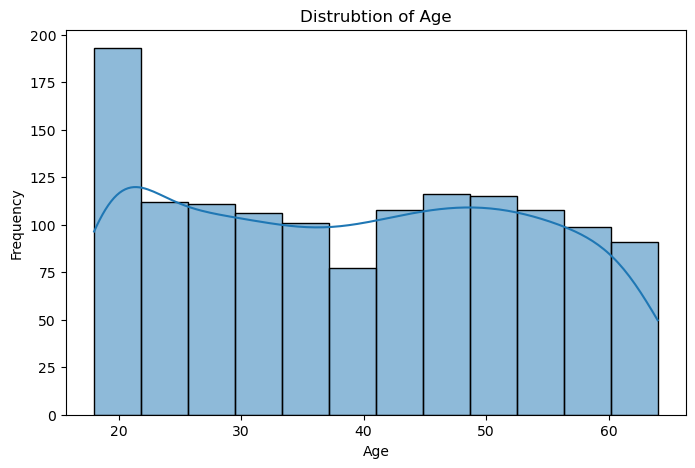

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"],kde=True)
plt.title("Distrubtion of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

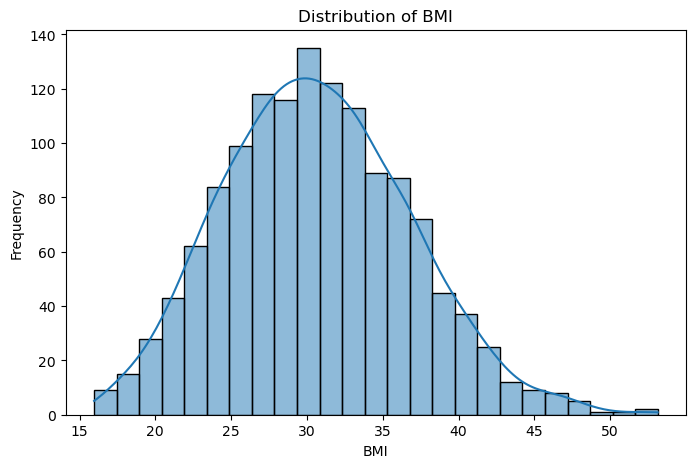

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["bmi"], kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

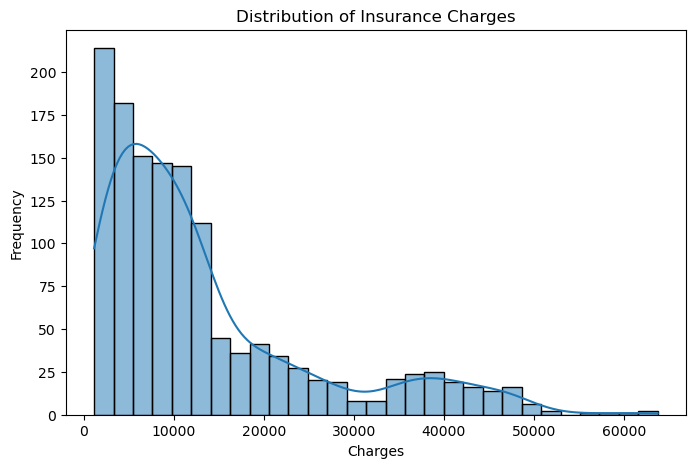

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

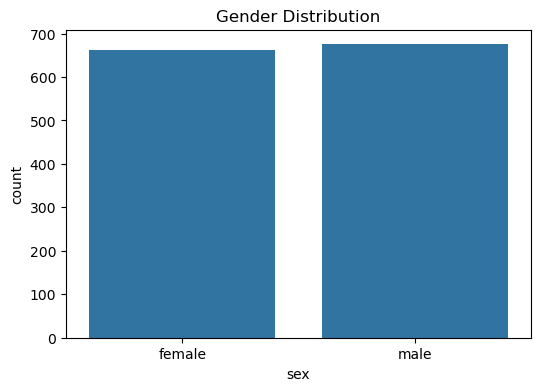

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["sex"])
plt.title("Gender Distribution")
plt.show()

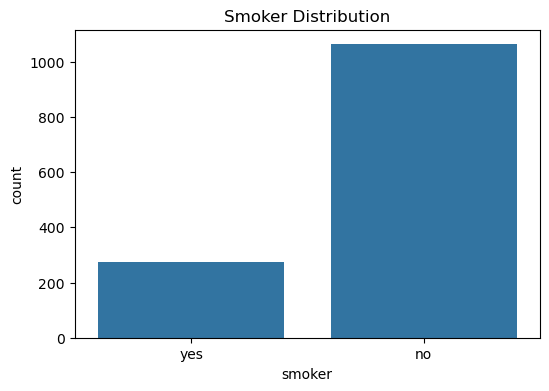

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["smoker"])
plt.title("Smoker Distribution")
plt.show()

In [26]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

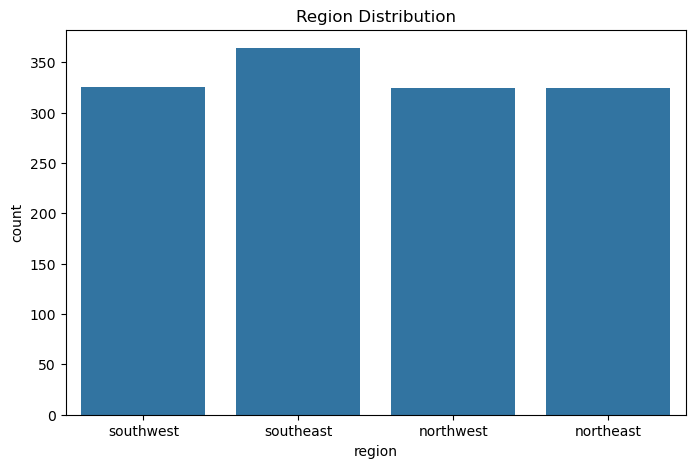

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["region"])

plt.title("Region Distribution")

plt.show()

# Outlier Analysis

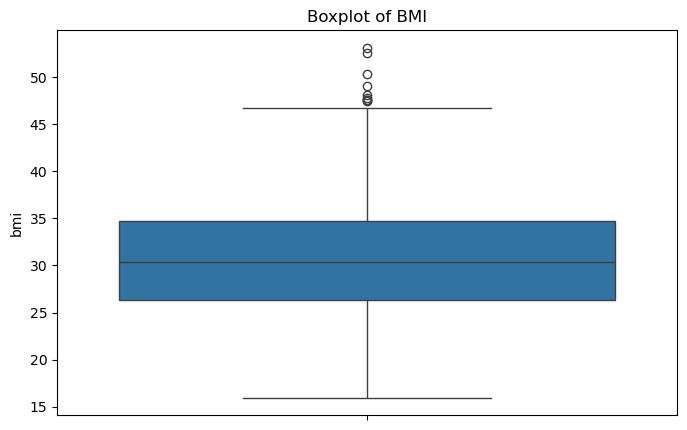

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(df["bmi"])
plt.title("Boxplot of BMI")
plt.show()

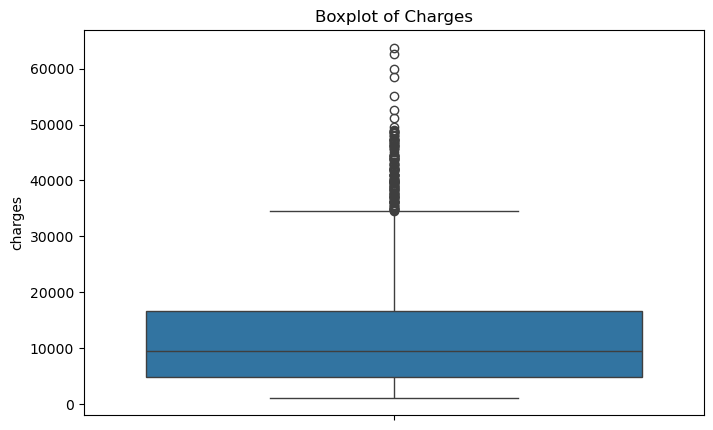

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(df["charges"])

plt.title("Boxplot of Charges")

plt.show()

# EDA Observations

- Age distribution appears relatively balanced.
- BMI values are concentrated around the normal to overweight range.
- Insurance charges are positively skewed.
- Majority of individuals are non-smokers.
- Some outliers are present in BMI and insurance charges.

# 4. Bivariate Analysis

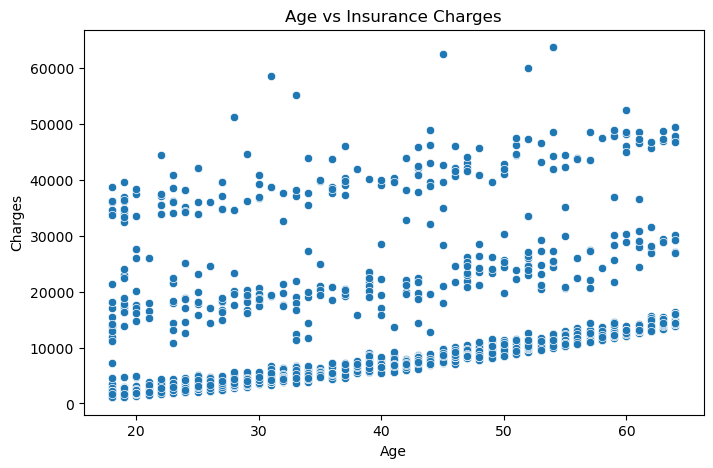

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["age"], y=df["charges"])

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

In [31]:
pearson_corr, _ = pearsonr(df["age"], df["charges"])

print("Pearson Correlation:", pearson_corr)

Pearson Correlation: 0.29830821250978734


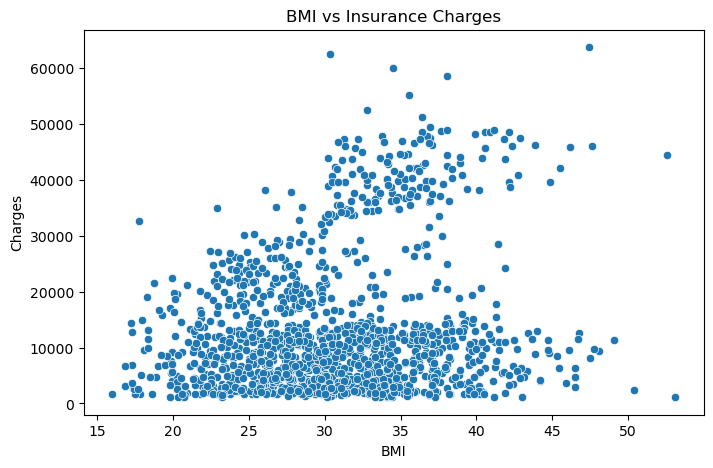

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["bmi"], y=df["charges"])

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

In [33]:
pearson_corr_bmi, _ = pearsonr(df["bmi"], df["charges"])

print("Pearson Correlation:", pearson_corr_bmi)

Pearson Correlation: 0.19840083122624944


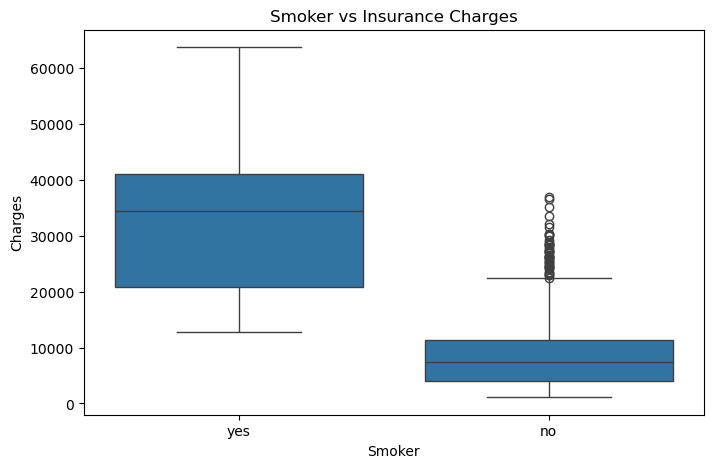

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["smoker"], y=df["charges"])

plt.title("Smoker vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

In [35]:
# smokers have MUCH higher charges

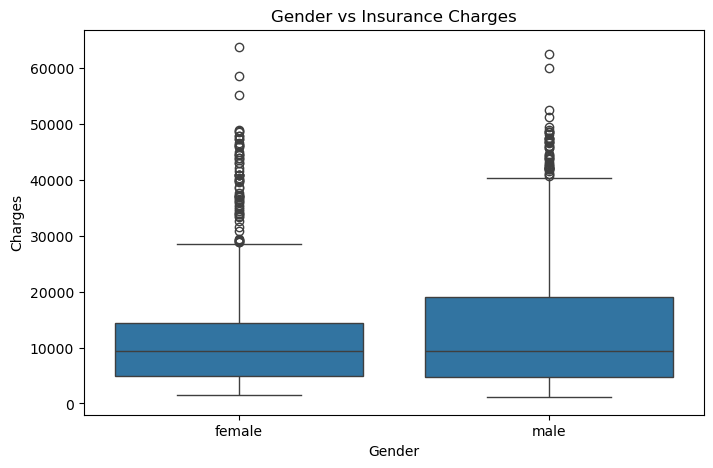

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["sex"], y=df["charges"])

plt.title("Gender vs Insurance Charges")
plt.xlabel("Gender")
plt.ylabel("Charges")

plt.show()

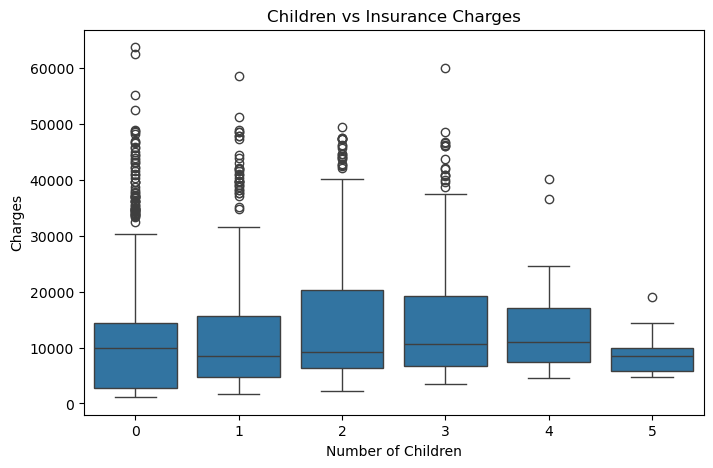

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["children"], y=df["charges"])

plt.title("Children vs Insurance Charges")
plt.xlabel("Number of Children")
plt.ylabel("Charges")

plt.show()

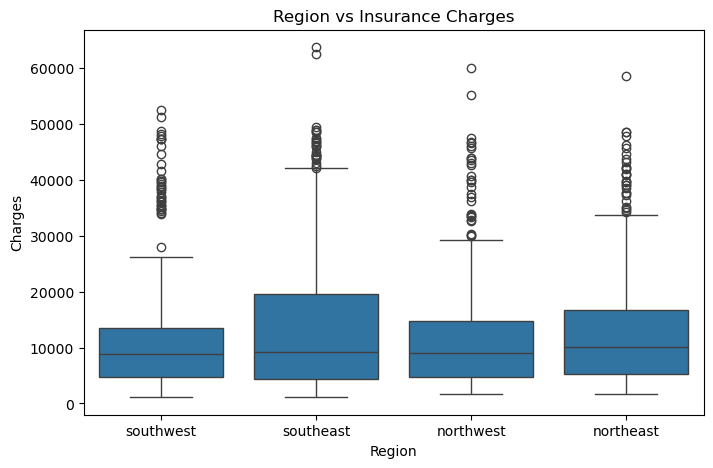

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["region"], y=df["charges"])

plt.title("Region vs Insurance Charges")
plt.xlabel("Region")
plt.ylabel("Charges")

plt.show()

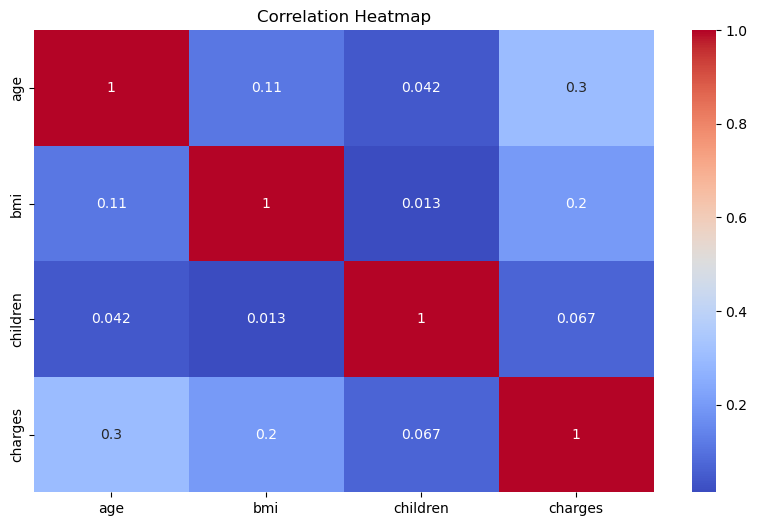

In [39]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Bivariate Analysis Observations

- Insurance charges tend to increase with age.
- BMI shows a moderate positive relationship with charges.
- Smokers have significantly higher insurance charges compared to non-smokers.
- Gender does not show a major difference in insurance charges.
- Region has limited impact on charges.

In [40]:
# 5. Feature Engineering

In [41]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [42]:
df["bmi"]

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1337, dtype: float64

In [43]:
def bmi_category(x):
    
    if x < 18.5:
        return "Underweight"
    
    elif x < 25:
        return "Normal"
    
    elif x < 30:
        return "Overweight"
    
    else:
        return "Obese"

In [44]:
df["bmi_category"] = df["bmi"].apply(bmi_category)

In [45]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Overweight


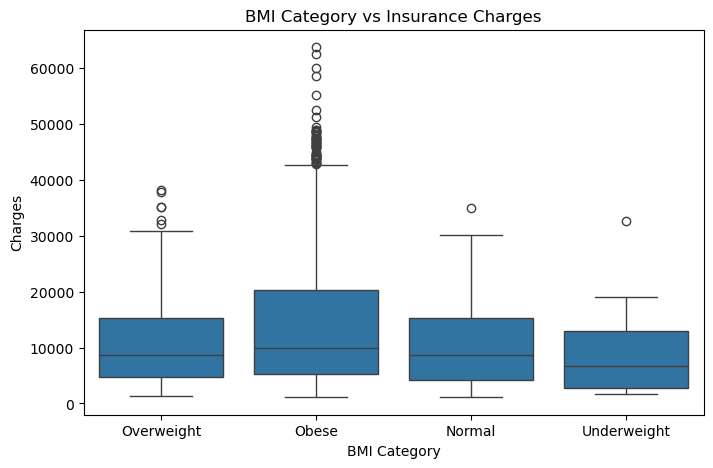

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["bmi_category"], y=df["charges"])

plt.title("BMI Category vs Insurance Charges")
plt.xlabel("BMI Category")
plt.ylabel("Charges")

plt.show()

In [47]:
df["family_size"] = df["children"] + 1

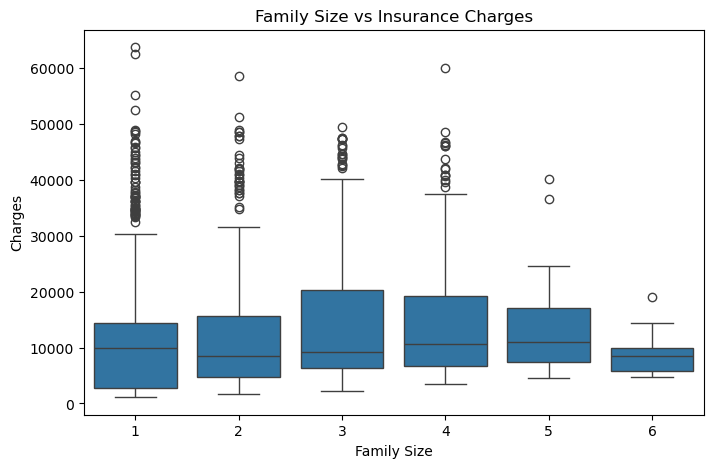

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["family_size"], y=df["charges"])

plt.title("Family Size vs Insurance Charges")
plt.xlabel("Family Size")
plt.ylabel("Charges")

plt.show()

In [49]:
df.groupby("bmi_category")["charges"].mean()

bmi_category
Normal         10409.337709
Obese          15572.041945
Overweight     10987.509891
Underweight     8852.200585
Name: charges, dtype: float64

# Feature Engineering Observations

- Obese individuals tend to have higher insurance charges.
- BMI category provides better interpretability compared to raw BMI values.
- Family size may influence insurance costs.
- Feature engineering helps improve business understanding of the dataset.

# 6. Data Preprocessing

In [50]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category', 'family_size'],
      dtype='object')

In [51]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,family_size
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,1
1,18,male,33.770,1,no,southeast,1725.55230,Obese,2
2,28,male,33.000,3,no,southeast,4449.46200,Obese,4
3,33,male,22.705,0,no,northwest,21984.47061,Normal,1
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,1


In [52]:
df["sex"] = df["sex"].map({
    "male":1,
    "female":0
})

df["smoker"] = df["smoker"].map({
    "yes":1,
    "no":0
})

In [53]:
df = pd.get_dummies(df,
                    columns=["region", "bmi_category"],
                    drop_first=True)

In [54]:
df.head()

,age,sex,bmi,children,smoker,charges,family_size,region_northwest,region_southeast,region_southwest,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,0,27.900,0,1,16884.92400,1,False,False,True,False,True,False
1,18,1,33.770,1,0,1725.55230,2,False,True,False,True,False,False
2,28,1,33.000,3,0,4449.46200,4,False,True,False,True,False,False
3,33,1,22.705,0,0,21984.47061,1,True,False,False,False,False,False
4,32,1,28.880,0,0,3866.85520,1,True,False,False,False,True,False


In [55]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [56]:
print(X.shape)
print(y.shape)

(1337, 12)
(1337,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Data Preprocessing Observations

- Categorical features were encoded into numerical format.
- Feature scaling was applied using StandardScaler.
- Dataset was divided into training and testing sets.
- Data is now ready for machine learning model training.

In [59]:
X.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'family_size',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Obese', 'bmi_category_Overweight',
       'bmi_category_Underweight'],
      dtype='object')

# 7. Model Building and Evaluation

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [61]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [62]:
y_pred_linear = linear_model.predict(X_test_scaled)

In [63]:
linear_mae = mean_absolute_error(y_test, y_pred_linear)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MAE : 4334.481444882433
RMSE: 6023.8562402869
R2 Score: 0.8025270937696651


## Polynomial Regression

In [64]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

In [65]:
scaler_poly = StandardScaler()

X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)

X_test_poly_scaled = scaler_poly.transform(X_test_poly)

In [66]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly_scaled, y_train)

LinearRegression()

In [67]:
y_pred_poly = poly_model.predict(X_test_poly_scaled)

In [68]:
poly_mae = mean_absolute_error(y_test, y_pred_poly)

poly_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_poly)
)

poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Results")
print("MAE :", poly_mae)
print("RMSE:", poly_rmse)
print("R2 Score:", poly_r2)

Polynomial Regression Results
MAE : 2614.2444843887342
RMSE: 4609.666090449183
R2 Score: 0.8843628830628173


## Random Forest Regressor

In [69]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [70]:
y_pred_rf = rf_model.predict(X_test)

In [71]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE : 2628.396576553358
RMSE: 4678.133147028566
R2 Score: 0.8809022719574983


In [72]:
model_results = pd.DataFrame({
    
    "Model":[
        "Linear Regression",
        "Polynomial Regression",
        "Random Forest"
    ],
    
    "MAE":[
        linear_mae,
        poly_mae,
        rf_mae
    ],
    
    "RMSE":[
        linear_rmse,
        poly_rmse,
        rf_rmse
    ],
    
    "R2 Score":[
        linear_r2,
        poly_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4334.481445,6023.856240,0.802527
1,Polynomial Regression,2614.244484,4609.666090,0.884363
2,Random Forest,2628.396577,4678.133147,0.880902


# Model Evaluation Observations

- Multiple machine learning models were trained and evaluated.
- Polynomial Regression captured non-linear relationships better than Linear Regression.
- Random Forest Regressor achieved the best predictive performance.
- Ensemble methods improved prediction accuracy significantly.

# 8. Final Conclusion

# Final Conclusion

This project focused on predicting medical insurance charges using machine learning techniques.

Key findings from the analysis include:

- Age and BMI show a positive relationship with insurance charges.
- Smoking status has the strongest impact on insurance costs.
- Obese individuals generally exhibit higher medical charges.
- Feature engineering improved business understanding of the dataset.
- Polynomial Regression performed better than basic Linear Regression by capturing non-linear relationships.
- Random Forest Regressor achieved the best overall predictive performance among all models tested.

Overall, this project demonstrates the complete machine learning workflow including:
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation

# 9. Model Saving

In [73]:
import joblib

joblib.dump(rf_model, "insurance_model.pkl")

['insurance_model.pkl']

In [74]:
loaded_model = joblib.load("insurance_model.pkl")